# Floyd–Warshall on CPU and GPU (Numba CUDA)

This notebook provides:

- A NumPy baseline implementation of Floyd–Warshall (all-pairs shortest paths)
- A Numba CUDA kernel that mirrors the classic per-`k` GPU update
- A small correctness check on a toy graph
- Simple timing comparison on a random dense graph (if a CUDA GPU is available)

## Extended work
- GPU partial blocking for 2D matrix
- Runtime vs Speed scaling benchmarks 


In [3]:
# import ctypes
# ctypes.CDLL("libcuda.so")
# print("CUDA driver loaded")

In [1]:
from numba import cuda
cuda.detect()

Found 1 CUDA devices
id 0    b'NVIDIA GeForce RTX 5060 Laptop GPU'                              [SUPPORTED]
                      Compute Capability: 12.0
                           PCI Device ID: 0
                              PCI Bus ID: 1
                                    UUID: GPU-d8f731d7-3dce-e7ea-7cf2-4a85f02cada5
                                Watchdog: Enabled
             FP32/FP64 Performance Ratio: 16
Summary:
	1/1 devices are supported


True

In [2]:
import numpy as np
import math, time
try:
    from numba import cuda
    has_cuda = cuda.is_available()
except Exception:
    has_cuda = False
print("CUDA available:", has_cuda)

CUDA available: True


## NumPy baseline implementation

We use the standard triple-loop Floyd–Warshall algorithm on a dense adjacency matrix.


In [3]:
INF = 1e20

def floyd_warshall_numpy(W: np.ndarray) -> np.ndarray:
    """In-place Floyd–Warshall on a dense NumPy array.
    W[i, j] is the initial distance (INF if no edge)."""
    D = W.copy().astype(np.float32)
    n = D.shape[0]
    for k in range(n):
        Dik = D[:, k][:, None]     # shape (n,1)
        Dkj = D[k, :][None, :]     # shape (1,n)
        D = np.minimum(D, Dik + Dkj)
    return D


## Numba CUDA kernel

We mirror the CUDA C++ kernel: for each fixed `k`, launch a 2D grid of threads
and let each thread update one `(i,j)` entry.


In [4]:
if has_cuda:
    from numba import cuda, float32

    @cuda.jit
    def floyd_step_kernel(D, n, k):
        i, j = cuda.grid(2)
        if i < n and j < n:
            Dik = D[i, k]
            Dkj = D[k, j]
            alt = Dik + Dkj
            if alt < D[i, j]:
                D[i, j] = alt

    def floyd_warshall_numba_cuda(W: np.ndarray) -> np.ndarray:
        D_host = W.astype(np.float32)
        n = D_host.shape[0]
        D_dev = cuda.to_device(D_host)
        threads = (16, 16)
        blocks = ((n + threads[0] - 1) // threads[0],
                  (n + threads[1] - 1) // threads[1])
        for k in range(n):
            floyd_step_kernel[blocks, threads](D_dev, n, k)
        cuda.synchronize()
        return D_dev.copy_to_host()
else:
    def floyd_warshall_numba_cuda(W: np.ndarray) -> np.ndarray:
        raise RuntimeError("CUDA is not available in this environment.")

## Toy example for correctness

We test on a small 4-node graph where we know the expected answer.


In [5]:
W = np.array([
    [0, 3, INF, 7],
    [8, 0, 2, INF],
    [5, INF, 0, 1],
    [2, INF, INF, 0]
], dtype=np.float32)

D_cpu = floyd_warshall_numpy(W)
print("CPU result:\n", D_cpu)

if has_cuda:
    D_gpu = floyd_warshall_numba_cuda(W)
    print("GPU result:\n", D_gpu)
    diff = np.max(np.abs(D_cpu - D_gpu))
    print("Max abs diff CPU vs GPU:", diff)
else:
    print("CUDA not available; skipping GPU test.")

CPU result:
 [[0. 3. 5. 6.]
 [5. 0. 2. 3.]
 [3. 6. 0. 1.]
 [2. 5. 7. 0.]]
GPU result:
 [[0. 3. 5. 6.]
 [5. 0. 2. 3.]
 [3. 6. 0. 1.]
 [2. 5. 7. 0.]]
Max abs diff CPU vs GPU: 0.0


/home/stella/neu_retrieval_netexp/network/lib/python3.10/site-packages/numba/cuda/dispatcher.py:536: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


## Simple timing comparison

We generate a random dense graph and compare NumPy vs. Numba CUDA timings.


In [6]:
def random_graph(n, edge_prob=0.6, max_w=10.0, seed=42):
    rng = np.random.default_rng(seed)
    W = np.full((n, n), INF, dtype=np.float32)
    for i in range(n):
        W[i, i] = 0.0
        for j in range(n):
            if i == j:
                continue
            if rng.random() < edge_prob:
                W[i, j] = rng.uniform(1.0, max_w)
    return W

n = 256  # adjust up if you have a strong GPU
W_rand = random_graph(n)

t0 = time.time()
D_cpu = floyd_warshall_numpy(W_rand)
t1 = time.time()
print(f"NumPy (CPU) time for n={n}: {(t1 - t0)*1000:.1f} ms")

if has_cuda:
    t2 = time.time()
    D_gpu = floyd_warshall_numba_cuda(W_rand)
    t3 = time.time()
    print(f"Numba CUDA time for n={n}: {(t3 - t2)*1000:.1f} ms")
    diff = np.max(np.abs(D_cpu - D_gpu))
    print("Max abs diff CPU vs GPU:", diff)
else:
    print("CUDA not available; skipping GPU timing.")


NumPy (CPU) time for n=256: 6.5 ms
Numba CUDA time for n=256: 6.9 ms
Max abs diff CPU vs GPU: 0.0


## Option B & C

##### 1. GPU-side modernization: 

In [7]:
TILE = 16
INF = 1e20

@cuda.jit
def floyd_step_tiled_kernel(D, n, k):

    # Global indices
    i, j = cuda.grid(2)

    # Thread indices inside tile
    tx = cuda.threadIdx.x
    ty = cuda.threadIdx.y

    # Shared memory tile
    sD = cuda.shared.array((TILE, TILE), float32)

    # Load tile from global memory
    if i < n and j < n:
        sD[ty, tx] = D[i, j]
    else:
        sD[ty, tx] = INF

    cuda.syncthreads()

    # Compute Floyd–Warshall update
    if i < n and j < n:
        alt = D[i, k] + D[k, j]

        if alt < sD[ty, tx]:
            sD[ty, tx] = alt

    cuda.syncthreads()

    # Write back tile
    if i < n and j < n:
        D[i, j] = sD[ty, tx]

In [8]:
#wrap
#D[i, k], D[k, j] are still read from global memory for each iteration hence partial blocking 

def floyd_warshall_numba_cuda_tiled(W):

    D_host = W.astype(np.float32)
    n = D_host.shape[0]

    D_dev = cuda.to_device(D_host)

    threads = (TILE, TILE)
    blocks = (
        (n + TILE - 1) // TILE,
        (n + TILE - 1) // TILE
    )

    for k in range(n):
        floyd_step_tiled_kernel[blocks, threads](D_dev, n, k)

    cuda.synchronize()

    return D_dev.copy_to_host()

In [11]:
#benchmarking script
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# sizes to test
sizes = [256, 512, 1024, 2048]

results = []

for n in sizes:

    print(f"\nRunning n={n}")

    W = random_graph(n)
    # CPU baseline
    t0 = time.perf_counter()
    D_cpu = floyd_warshall_numpy(W)
    t1 = time.perf_counter()

    cpu_time = t1 - t0

    
    # GPU naive
    gpu_time = None
    tiled_time = None

    if has_cuda:

        t0 = time.perf_counter()
        D_gpu = floyd_warshall_numba_cuda(W)
        cuda.synchronize()
        t1 = time.perf_counter()

        gpu_time = t1 - t0

       
        # GPU tiled
        t0 = time.perf_counter()
        D_tile = floyd_warshall_numba_cuda_tiled(W)
        cuda.synchronize()
        t1 = time.perf_counter()

        tiled_time = t1 - t0

  
    # operations estimate
    ops = 2 * n**3

    results.append({
        "n": n,
        "cpu_time": cpu_time,
        "gpu_time": gpu_time,
        "gpu_tiled_time": tiled_time,
        "ops_estimate": ops
    })

df = pd.DataFrame(results)

# speedups
df["speedup_gpu"] = df["cpu_time"] / df["gpu_time"]
df["speedup_tiled"] = df["cpu_time"] / df["gpu_tiled_time"]

print("\nBenchmark Results")
print(df)


Running n=256

Running n=512

Running n=1024

Running n=2048

Benchmark Results
      n  cpu_time  gpu_time  gpu_tiled_time  ops_estimate  speedup_gpu  \
0   256  0.010450  0.007730        0.274508      33554432     1.351979   
1   512  0.077060  0.013929        0.014371     268435456     5.532178   
2  1024  0.729186  0.035828        0.044842    2147483648    20.352477   
3  2048  6.544392  0.168877        0.292161   17179869184    38.752398   

   speedup_tiled  
0       0.038069  
1       5.362280  
2      16.261237  
3      22.399987  


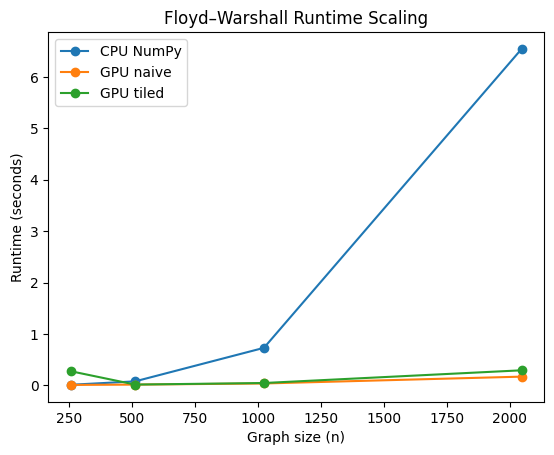

In [12]:
plt.figure()

plt.plot(df["n"], df["cpu_time"], marker="o", label="CPU NumPy")
plt.plot(df["n"], df["gpu_time"], marker="o", label="GPU naive")
plt.plot(df["n"], df["gpu_tiled_time"], marker="o", label="GPU tiled")

plt.xlabel("Graph size (n)")
plt.ylabel("Runtime (seconds)")
plt.title("Floyd–Warshall Runtime Scaling")
plt.legend()

plt.show()

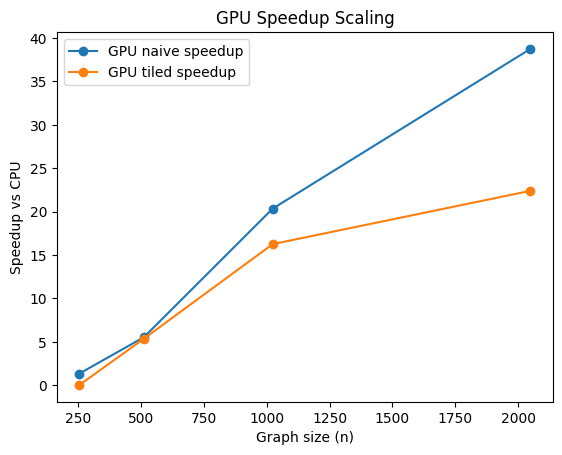

In [13]:
plt.figure()

plt.plot(df["n"], df["speedup_gpu"], marker="o", label="GPU naive speedup")
plt.plot(df["n"], df["speedup_tiled"], marker="o", label="GPU tiled speedup")

plt.xlabel("Graph size (n)")
plt.ylabel("Speedup vs CPU")
plt.title("GPU Speedup Scaling")

plt.legend()

plt.show()